# Google Play Store Analysis
## Oasis Infobyte — Data Analytics Internship
### Name: Priti Ranjit | Track: Data Analytics | Level 2 Task 4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load both datasets
apps = pd.read_csv('googleplaystore.csv')
reviews = pd.read_csv('googleplaystore_user_reviews.csv')

print("Apps Dataset Shape:", apps.shape)
print("Reviews Dataset Shape:", reviews.shape)
print("\nApps First 5 rows:")
apps.head()

Apps Dataset Shape: (10841, 13)
Reviews Dataset Shape: (64295, 5)

Apps First 5 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## Step 1: Data Cleaning
Fix incorrect data types, handle nulls, remove duplicates.

In [3]:
print("Missing values in Apps dataset:")
print(apps.isnull().sum())
print("\nDuplicate rows:", apps.duplicated().sum())

# Remove duplicates
apps = apps.drop_duplicates()

# Remove rows with missing values
apps = apps.dropna()

# Fix Installs column - remove + and , 
apps['Installs'] = apps['Installs'].str.replace('+', '', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

# Fix Size column
apps['Size'] = apps['Size'].str.replace('M', '', regex=False)
apps['Size'] = apps['Size'].str.replace('k', '', regex=False)
apps['Size'] = pd.to_numeric(apps['Size'], errors='coerce')

# Fix Price column
apps['Price'] = apps['Price'].str.replace('$', '', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

# Fix Rating column
apps['Rating'] = pd.to_numeric(apps['Rating'], errors='coerce')

print("\nShape after cleaning:", apps.shape)
print("Data types after fixing:")
print(apps.dtypes)

Missing values in Apps dataset:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Duplicate rows: 483

Shape after cleaning: (8886, 13)
Data types after fixing:
App                   str
Category              str
Rating            float64
Reviews               str
Size              float64
Installs            int64
Type                  str
Price             float64
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object


## Step 2: Category Analysis
Which categories are most saturated?

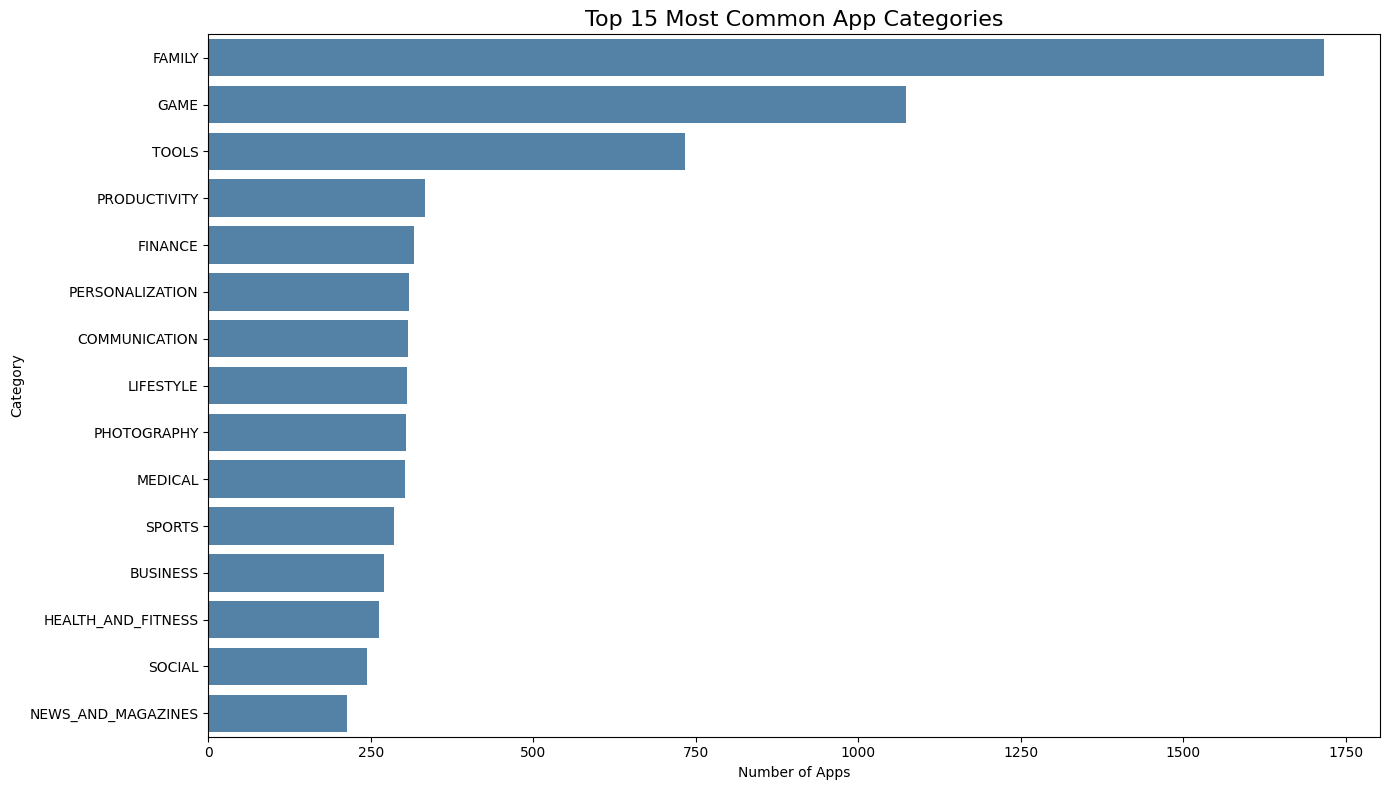

Top 5 most saturated categories:
Category
FAMILY          1717
GAME            1074
TOOLS            733
PRODUCTIVITY     334
FINANCE          317
Name: count, dtype: int64


In [4]:
plt.figure(figsize=(14, 8))
category_counts = apps['Category'].value_counts().head(15)
sns.barplot(x=category_counts.values, 
            y=category_counts.index, color='steelblue')
plt.title('Top 15 Most Common App Categories', fontsize=16)
plt.xlabel('Number of Apps')
plt.tight_layout()
plt.savefig('category_distribution.png')
plt.show()

print("Top 5 most saturated categories:")
print(category_counts.head())

## Step 3: Ratings Analysis
Distribution of app ratings and average rating by category.

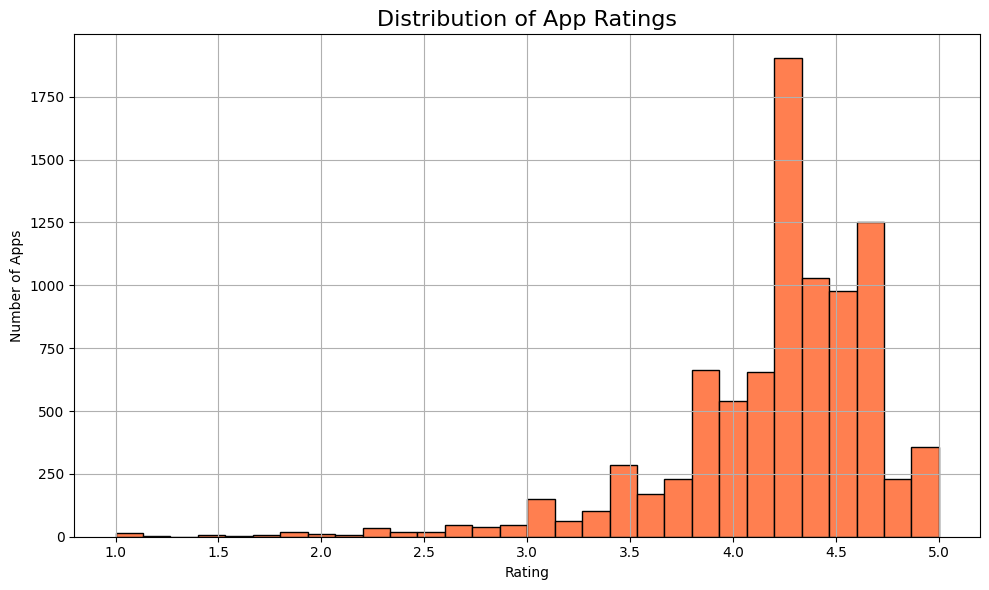

Average Rating: 4.19
Median Rating: 4.3


In [5]:
plt.figure(figsize=(10, 6))
apps['Rating'].hist(bins=30, color='coral', edgecolor='black')
plt.title('Distribution of App Ratings', fontsize=16)
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.savefig('ratings_distribution.png')
plt.show()

print("Average Rating:", apps['Rating'].mean().round(2))
print("Median Rating:", apps['Rating'].median())

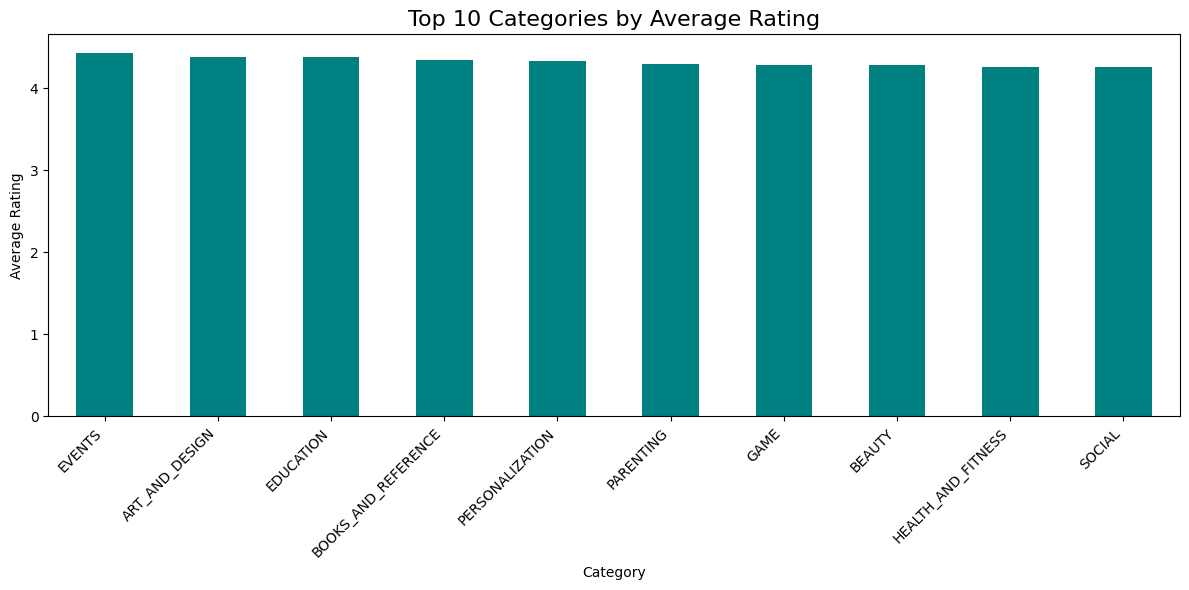

In [6]:
avg_rating = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
avg_rating.plot(kind='bar', color='teal')
plt.title('Top 10 Categories by Average Rating', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('avg_rating_by_category.png')
plt.show()

## Step 4: Size and Installs Analysis
Is there a correlation between app size and number of installs?

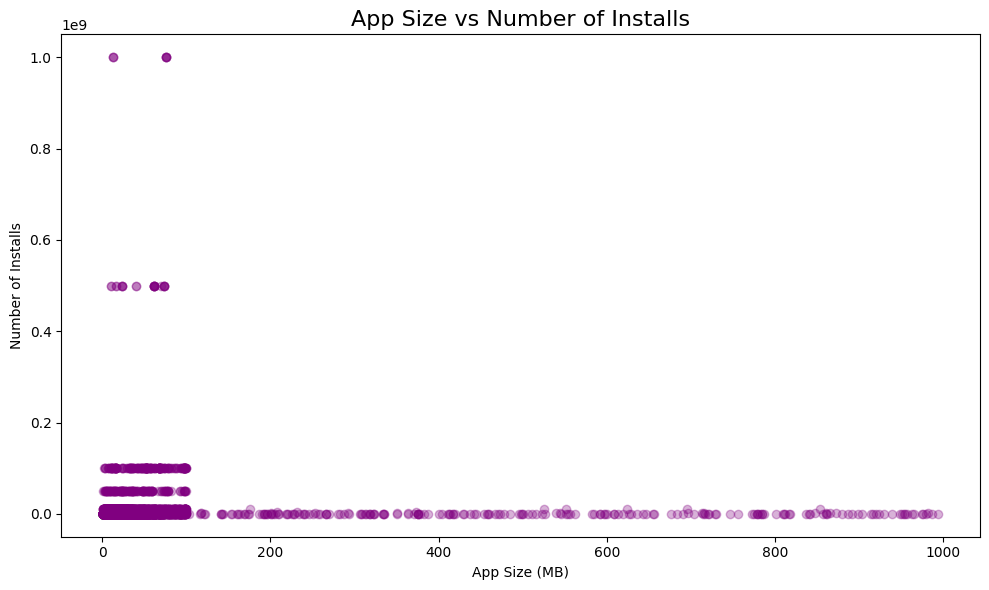

Correlation between Size and Installs: 0.0164


In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(apps['Size'], apps['Installs'], 
            alpha=0.3, color='purple')
plt.title('App Size vs Number of Installs', fontsize=16)
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Installs')
plt.tight_layout()
plt.savefig('size_vs_installs.png')
plt.show()

correlation = apps['Size'].corr(apps['Installs'])
print(f"Correlation between Size and Installs: {correlation:.4f}")

## Step 5: Pricing Analysis
Paid vs free app distribution and revenue estimates.

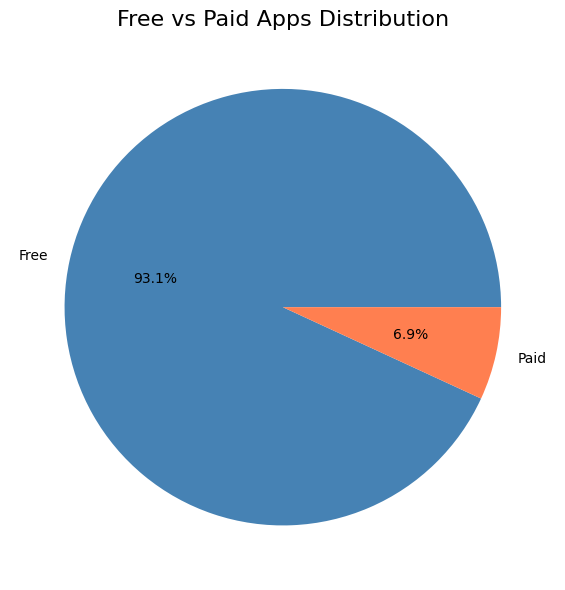

Type
Free    8275
Paid     611
Name: count, dtype: int64


In [8]:
plt.figure(figsize=(8, 6))
apps['Type'].value_counts().plot(kind='pie', 
                                   autopct='%1.1f%%',
                                   colors=['steelblue', 'coral'])
plt.title('Free vs Paid Apps Distribution', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.savefig('free_vs_paid.png')
plt.show()

print(apps['Type'].value_counts())

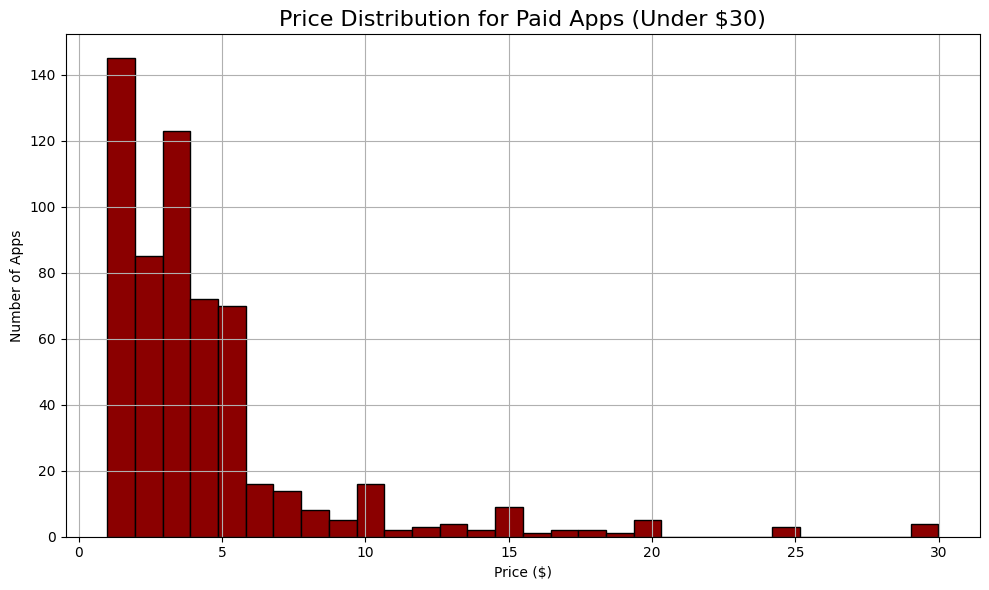

Average Price of Paid Apps: $ 14.01
Median Price of Paid Apps: $ 2.99


In [9]:
paid_apps = apps[apps['Type'] == 'Paid']

plt.figure(figsize=(10, 6))
paid_apps[paid_apps['Price'] < 30]['Price'].hist(
    bins=30, color='darkred', edgecolor='black')
plt.title('Price Distribution for Paid Apps (Under $30)', fontsize=16)
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.savefig('price_distribution.png')
plt.show()

print("Average Price of Paid Apps: $", paid_apps['Price'].mean().round(2))
print("Median Price of Paid Apps: $", paid_apps['Price'].median())

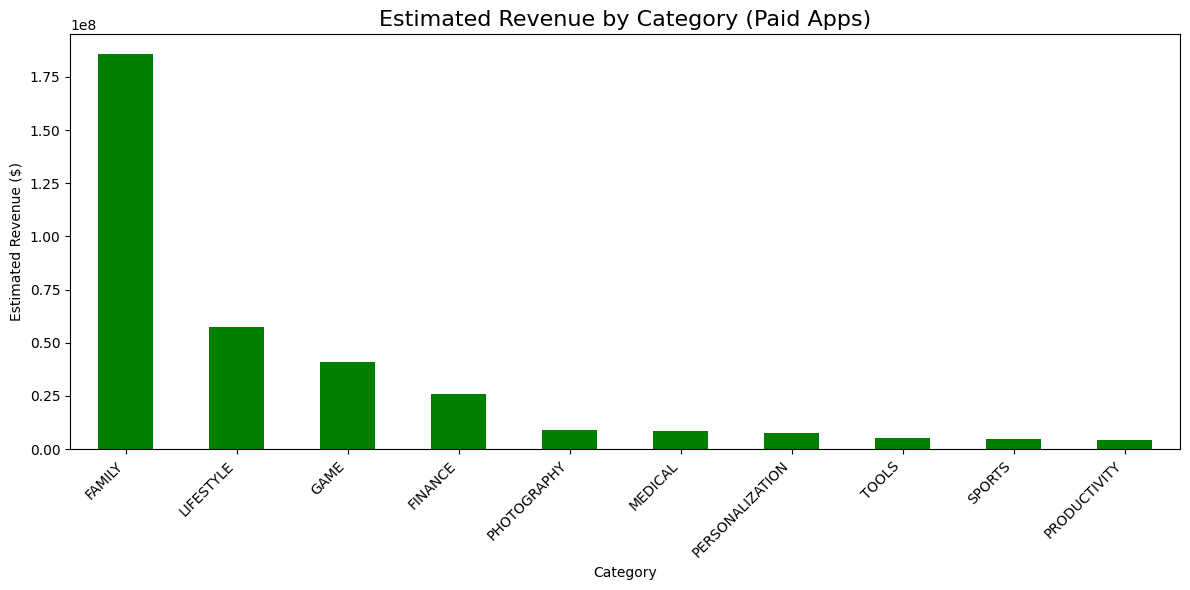

In [10]:
paid_apps['Revenue'] = paid_apps['Price'] * paid_apps['Installs']
revenue_by_category = paid_apps.groupby('Category')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
revenue_by_category.plot(kind='bar', color='green')
plt.title('Estimated Revenue by Category (Paid Apps)', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Estimated Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('revenue_by_category.png')
plt.show()

## Step 6: Sentiment Analysis on User Reviews
Classify reviews as Positive, Negative, or Neutral using TextBlob.

In [11]:
print("Reviews Dataset Info:")
print(reviews.shape)
print(reviews.columns.tolist())
print(reviews.isnull().sum())

# Drop missing reviews
reviews_clean = reviews.dropna(subset=['Translated_Review'])
print("\nShape after cleaning:", reviews_clean.shape)
reviews_clean.head()

Reviews Dataset Info:
(64295, 5)
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

Shape after cleaning: (37427, 5)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000


In [12]:
def get_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

reviews_clean['Sentiment'] = reviews_clean['Translated_Review'].apply(get_sentiment)

print("Sentiment Distribution:")
print(reviews_clean['Sentiment'].value_counts())

Sentiment Distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


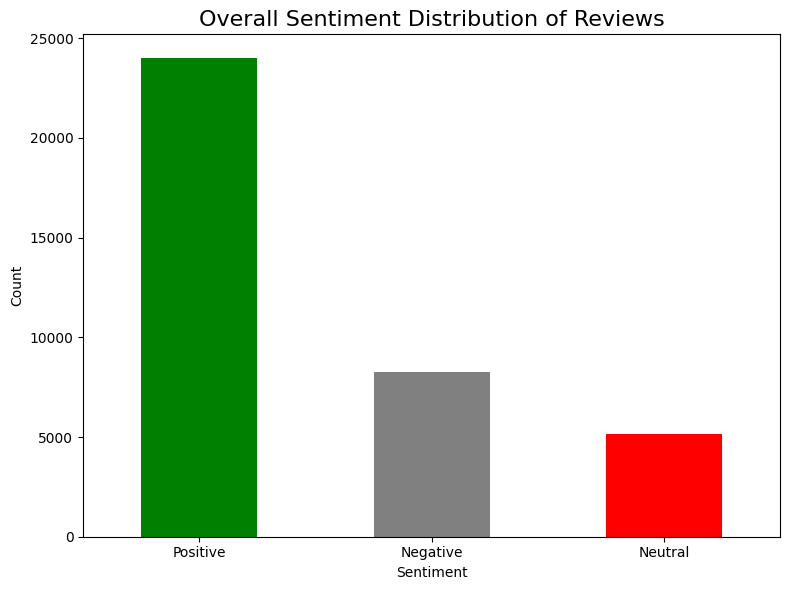

In [13]:
plt.figure(figsize=(8, 6))
reviews_clean['Sentiment'].value_counts().plot(
    kind='bar', color=['green', 'gray', 'red'])
plt.title('Overall Sentiment Distribution of Reviews', fontsize=16)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

<Figure size 1400x800 with 0 Axes>

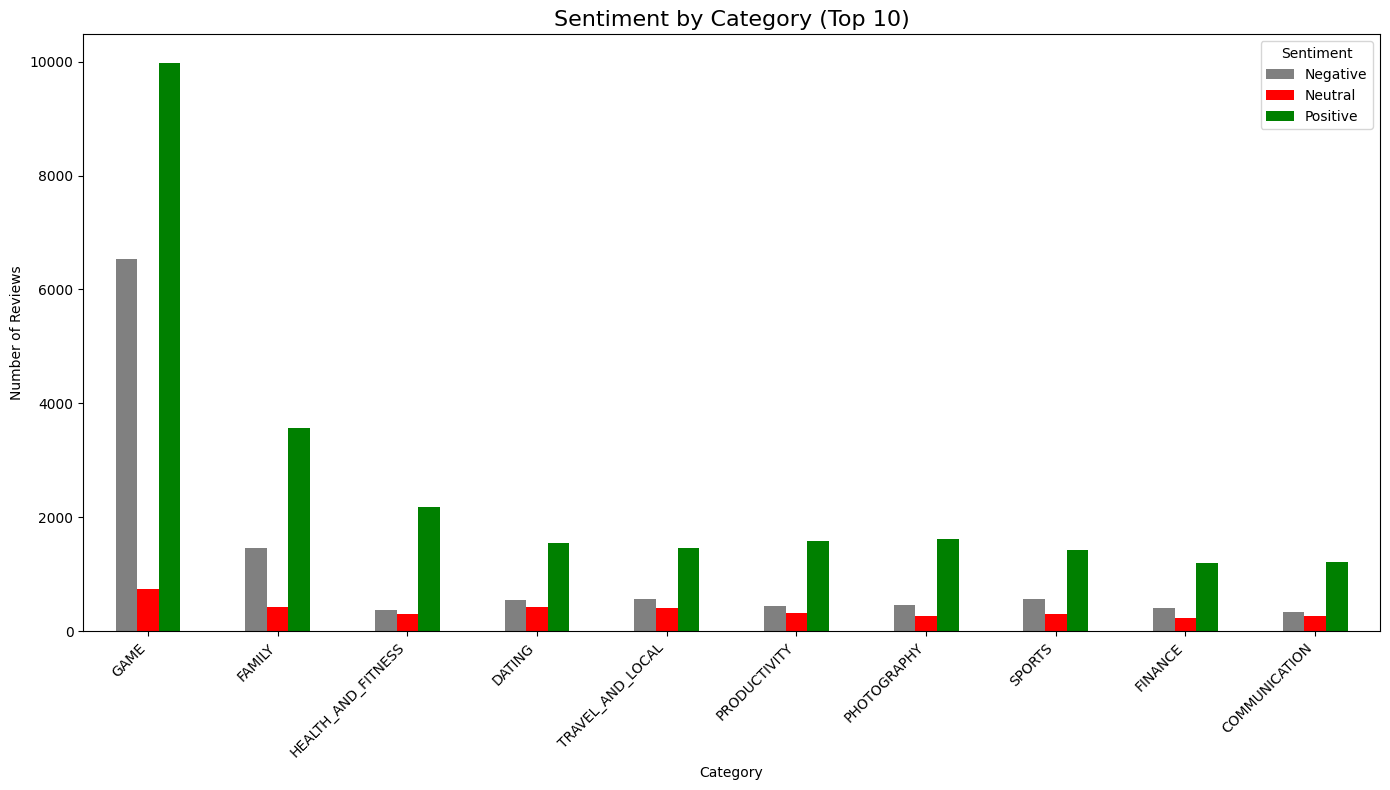

In [14]:
# Merge apps and reviews
merged = reviews_clean.merge(
    apps[['App', 'Category']], on='App', how='left')

# Sentiment by category
sentiment_category = merged.groupby(
    ['Category', 'Sentiment']).size().unstack(fill_value=0)

# Top 10 categories by total reviews
top_categories = sentiment_category.sum(axis=1).sort_values(
    ascending=False).head(10).index

plt.figure(figsize=(14, 8))
sentiment_category.loc[top_categories].plot(
    kind='bar', color=['gray', 'red', 'green'],
    figsize=(14, 8))
plt.title('Sentiment by Category (Top 10)', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('sentiment_by_category.png')
plt.show()

## Step 7: Additional Insight — Top Free vs Paid Apps

In [15]:
top_free = apps[apps['Type']=='Free'].nlargest(10, 'Installs')[['App', 'Category', 'Installs', 'Rating']]
print("Top 10 Free Apps by Installs:")
print(top_free.to_string(index=False))

Top 10 Free Apps by Installs:
                                     App            Category   Installs  Rating
                       Google Play Books BOOKS_AND_REFERENCE 1000000000     3.9
Messenger – Text and Video Chat for Free       COMMUNICATION 1000000000     4.0
                      WhatsApp Messenger       COMMUNICATION 1000000000     4.4
            Google Chrome: Fast & Secure       COMMUNICATION 1000000000     4.3
                                   Gmail       COMMUNICATION 1000000000     4.3
                                Hangouts       COMMUNICATION 1000000000     4.0
Messenger – Text and Video Chat for Free       COMMUNICATION 1000000000     4.0
                                Hangouts       COMMUNICATION 1000000000     4.0
           Skype - free IM & video calls       COMMUNICATION 1000000000     4.1
            Google Chrome: Fast & Secure       COMMUNICATION 1000000000     4.3


## Conclusion

### Key Findings:
1. **Family and Game categories** are the most saturated — 
   highest competition for new developers
2. **Average app rating** is around 4.1 — users generally 
   rate apps positively
3. **93% of apps are free** — freemium model dominates 
   the Play Store
4. **Positive sentiment dominates** user reviews across 
   most categories
5. **App size has weak correlation** with installs — 
   quality matters more than size

### 3 Data-Driven Insights for a Developer:
1. **Launch in less saturated categories** like Beauty or 
   Events where competition is lower but demand exists
2. **Keep your app free** with in-app purchases — 93% of 
   successful apps use this model
3. **Focus on user experience** to maintain rating above 
   4.0 — apps below 3.5 get significantly fewer installs